In [94]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

df = pd.read_csv("gridsearch_4.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'results_b.csv'

In [91]:
first_feature = "hidden_activation"
second_feature = "output_activation"
df[first_feature] = df['params'].apply(lambda x: eval(x)[first_feature])
df[second_feature] = df['params'].apply(lambda x: eval(x)[second_feature])

first_category = df[first_feature].unique()
second_category = df[second_feature][::-1].unique()

df_temp = pd.DataFrame(columns=[first_feature,second_feature,'loss'])

for i in first_category:
    for j in second_category:
        temp = df[df[first_feature]==i]
        new_row = pd.DataFrame({
            first_feature: [i],
            second_feature: [j],
            'loss': [temp[temp[second_feature]==j]['loss'].mean()]
        })
        df_temp = pd.concat([df_temp, new_row]).reset_index(drop=True)

df = df_temp

/var/folders/07/drqjjvn175xc67mww0s1djch0000gn/T/ipykernel_7309/1226367391.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_temp = pd.concat([df_temp, new_row]).reset_index(drop=True)


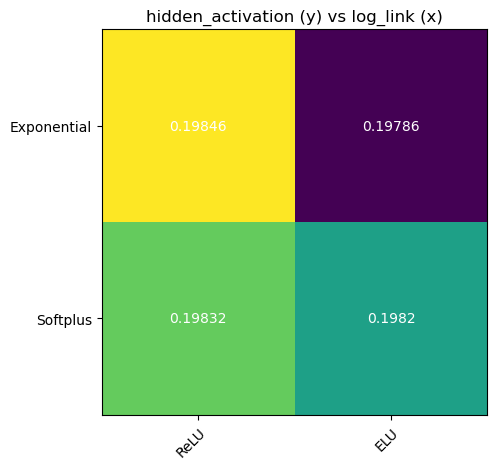

In [93]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib
import matplotlib as mpl


data = np.array(df['loss']).reshape(len(first_category),len(second_category)).T

fig, ax = plt.subplots()
im = ax.imshow(data)

# Show all ticks and label them with the respective list entries
ax.set_xticks(range(len(first_category)), labels=first_category,
              rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(second_category)), labels=second_category)

# Loop over data dimensions and create text annotations.
for i in range(len(second_category)):
    for j in range(len(first_category)):
        text = ax.text(j, i, round(data[i, j],5),
                       ha="center", va="center", color="w")

# ax.set_title(first_feature + ' (y) vs ' +  second_feature + ' (x)')
ax.set_title(first_feature + ' (y) vs ' +  'log_link' + ' (x)')
fig.tight_layout()
plt.show()